# Proyecto Final — Minería de Datos
## Segmentación y predicción de siniestros viales en Bogotá D.C.

**Autor:** Erlyn Martínez — Ingeniería de Sistemas
**Dataset:** Siniestros Viales Consolidados Bogotá D.C. — hoja `SINIESTROS` (Secretaría Distrital de Movilidad, Datos Abiertos Bogotá), periodo 2015-2020
**Curso:** Minería de Datos — Proyecto Final (KDD)

Este notebook desarrolla el proceso completo de **KDD (Knowledge Discovery in Databases)** sobre la hoja `SINIESTROS` del dataset de siniestros viales de Bogotá, combinando una tarea **descriptiva (Clustering)** y una tarea **predictiva (Clasificación)** sobre el mismo dominio de negocio: la seguridad vial de la ciudad.

> **Nota de alcance:** el archivo original trae 5 hojas relacionadas (`SINIESTROS`, `ACTOR_VIAL`, `VEHICULOS`, `HIPOTESIS`, `DICCIONARIO`). Por indicación del enunciado, este proyecto se resuelve **únicamente con la hoja `SINIESTROS`** (196.152 registros, 10 columnas), sin cruzar con las demás hojas. La hoja `DICCIONARIO` sí se usa como referencia para decodificar los códigos.

El notebook está organizado en los 8 módulos de la rúbrica del proyecto:

1. Contexto y Selección de Datos
2. Preprocesamiento
3. Transformación de Datos
4. Tarea Descriptiva: Clustering
5. Tarea Predictiva: Modelos de Clasificación
6. Evaluación y Diagnóstico
7. Integración y Conclusiones
8. Comunicación y Documentación (resumen ejecutivo)

In [1]:
# Librerías generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

---
# 1. Contexto y Selección de Datos

## 1.1 Dominio de negocio

La **Secretaría Distrital de Movilidad de Bogotá (SDM)** administra el **SIGAT** (Sistema de Información Geográfico de Accidentes de Tránsito), que consolida el Informe Policial de Accidentes de Tránsito (IPAT) de cada siniestro vial ocurrido en la ciudad. Bogotá registra miles de siniestros viales cada año, y el Plan Distrital de Seguridad Vial busca reducir las víctimas fatales y priorizar recursos de prevención en las zonas y momentos de mayor riesgo.

Nos ponemos en el rol de un equipo de **analítica de datos de la SDM** que debe apoyar dos decisiones de negocio distintas con el mismo dataset:

- **Pregunta descriptiva (Clustering):** ¿existen perfiles o patrones característicos de siniestralidad (combinando zona, tipo de vía, momento del día/semana y clase de siniestro) que permitan agrupar los siniestros en segmentos accionables para priorizar intervenciones de infraestructura y campañas de prevención?
- **Pregunta predictiva (Clasificación):** ¿qué circunstancias del siniestro (localidad, tipo de vía, diseño del lugar, clase de siniestro, momento del día/semana) están asociadas a una mayor probabilidad de que el siniestro tenga víctimas (heridos o muertos) y no solo daños materiales? Esto permite priorizar recursos de prevención y de atención en las zonas/horarios de mayor riesgo.

Ambas preguntas comparten el mismo dominio (siniestralidad vial) y se retroalimentan: los perfiles del clustering ayudan a interpretar *dónde y cuándo* actuar, y el modelo predictivo ayuda a entender *qué variables* explican el riesgo de que haya víctimas (ver sección 7, donde se conectan ambos resultados).

## 1.2 Descripción del dataset

Se trabaja exclusivamente con la hoja **`SINIESTROS`** del archivo `siniestros_viales_consolidados_bogota_dc.xlsx` (dataset público y oficial de la Secretaría Distrital de Movilidad, Datos Abiertos Bogotá). No corresponde a ninguno de los datasets trabajados en clase (Titanic, Telco Churn, Ames Housing, Medical Insurance).

Cumple los criterios mínimos exigidos por el proyecto:
- **196.152 registros** (>> 500 mínimo) y **10 columnas** originales (>> 8 mínimo).
- Combina **variables numéricas/temporales** (fecha, hora) y **categóricas codificadas** (gravedad, clase de siniestro, tipo de choque, diseño del lugar, localidad).
- Presenta **problemas reales de calidad de datos**: valores faltantes estructurales (`CHOQUE`, `OBJETO_FIJO`), variables categóricas sin etiquetas de texto (solo códigos numéricos, que hay que decodificar con la hoja `DICCIONARIO`) y una variable de texto libre de altísima cardinalidad (`DIRECCION`, ~92.500 valores únicos) que requiere ingeniería de variables.

### Diccionario de datos (columnas originales de `SINIESTROS`)

| Columna | Descripción | Tipo |
|---|---|---|
| `CODIGO_ACCIDENTE` | Identificador único del siniestro | Numérico (llave) |
| `FECHA` | Fecha del siniestro (2015-2020) | Fecha |
| `HORA` | Hora del siniestro | Hora |
| `GRAVEDAD` | 1=Con muertos, 2=Con heridos, 3=Solo daños | Categórica ordinal |
| `CLASE` | 1=Choque, 2=Atropello, 3=Volcamiento, 4=Caída de ocupante, 5=Incendio, 6=Otro, 7=Autolesión | Categórica nominal |
| `CHOQUE` | Subtipo de choque (solo aplica si `CLASE`=1): 1=Vehículo, 2=Tren, 3=Semoviente, 4=Objeto fijo, 5=Otro | Categórica nominal |
| `OBJETO_FIJO` | Objeto fijo contra el que se chocó (solo aplica si `CHOQUE`=4) | Categórica nominal |
| `DIRECCION` | Dirección textual del siniestro (texto libre, alta cardinalidad) | Texto |
| `CODIGO_LOCALIDAD` | Código de la localidad de Bogotá (1 a 20) | Categórica nominal |
| `DISENO_LUGAR` | Diseño del lugar: 1=Tramo de vía, 2=Intersección, 3=Vía peatonal, 4=Paso elevado, 5=Paso inferior, 6=Paso a nivel, 7=Glorieta, 8=Puente, 9=Vía troncal, 10=Lote/predio, 11=Ciclorruta, 12=Pontón, 13=Túnel | Categórica nominal |

Las etiquetas de `GRAVEDAD`, `CLASE`, `CHOQUE`, `OBJETO_FIJO`, `CODIGO_LOCALIDAD` y `DISENO_LUGAR` provienen de la hoja `DICCIONARIO` incluida en el mismo archivo. El hecho de que el dataset original solo traiga códigos numéricos, sin las etiquetas de texto, es en sí mismo el primer problema de calidad de datos (información no autoexplicativa), y se resuelve decodificando con dicho diccionario.

## 1.3 Variables seleccionadas para cada tarea

- **Clustering (descriptiva):** localidad, clase de siniestro, diseño del lugar, tipo de vía (variable nueva, derivada de `DIRECCION`) y franja horaria / fin de semana (variables nuevas, derivadas de `HORA`/`FECHA`) — variables que describen el **contexto físico y temporal** del siniestro, sin usar la gravedad, para que los clusters describan *circunstancias*, no *resultados*.
- **Clasificación (predictiva):** las mismas variables de contexto (localidad, clase, tipo de choque, diseño del lugar, tipo de vía, variables temporales) para predecir una **variable objetivo nueva**, `SINIESTRO_CON_VICTIMAS`, derivada de `GRAVEDAD` (ver sección 3.2). Se excluye `GRAVEDAD` como predictor porque es la variable que se usa para *construir* el objetivo (para evitar fuga de información).

In [2]:
df = pd.read_excel('siniestros_viales_consolidados_bogota_dc.xlsx', sheet_name='SINIESTROS')
# FECHA llega como texto (dd/mm/aaaa); se corrige el tipo de dato desde el inicio
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y')
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 196,152 filas x 10 columnas


,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR
0,4401438,2015-01-01,01:05:00,2,2,NaN,NaN,KR 64A-CL 2C 02,16,2
1,4401449,2015-01-01,05:50:00,2,3,NaN,NaN,AV AVENIDA DEL SUR-KR 65A 41,7,1
2,4401430,2015-01-01,07:15:00,2,3,NaN,NaN,KR 19D-CL 62 S 02,19,1
3,4401453,2015-01-01,09:30:00,3,1,1.0,NaN,KR 79-CL 42F S 71,8,1
4,4401423,2015-01-01,09:45:00,2,1,1.0,NaN,CL 66A-KR 76 02,10,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 196152 entries, 0 to 196151
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   CODIGO_ACCIDENTE  196152 non-null  int64         
 1   FECHA             196152 non-null  datetime64[us]
 2   HORA              196152 non-null  str           
 3   GRAVEDAD          196152 non-null  int64         
 4   CLASE             196152 non-null  int64         
 5   CHOQUE            167910 non-null  float64       
 6   OBJETO_FIJO       6689 non-null    float64       
 7   DIRECCION         196152 non-null  str           
 8   CODIGO_LOCALIDAD  196152 non-null  int64         
 9   DISENO_LUGAR      196152 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(5), str(2)
memory usage: 15.0 MB


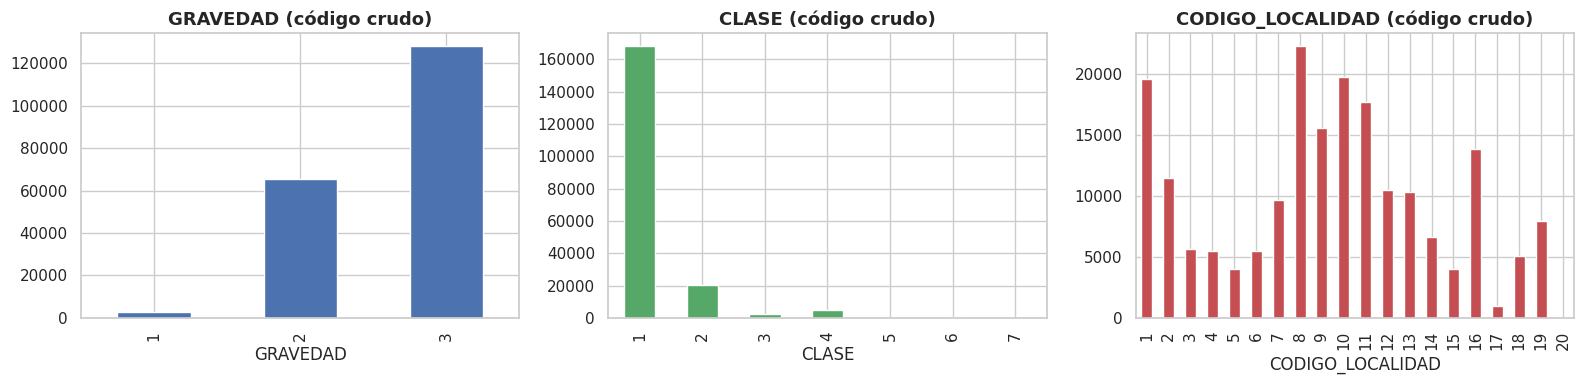

In [4]:
# Distribución general de las variables categóricas clave (con códigos crudos)
fig, axes = plt.subplots(1, 3, figsize=(16,4))
df['GRAVEDAD'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('GRAVEDAD (código crudo)')
df['CLASE'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('CLASE (código crudo)')
df['CODIGO_LOCALIDAD'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('CODIGO_LOCALIDAD (código crudo)')
plt.tight_layout()
plt.show()

---
# 2. Preprocesamiento

En esta sección se identifican y tratan: (a) valores faltantes, clasificando su mecanismo (MCAR/MAR/MNAR), (b) duplicados, y (c) valores atípicos/categorías raras, distinguiendo genuino vs. espurio.

## 2.1 Valores faltantes

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'faltantes': missing, 'porcentaje': missing_pct})
missing_df = missing_df[missing_df['faltantes'] > 0].sort_values('porcentaje', ascending=False)
missing_df

,faltantes,porcentaje
OBJETO_FIJO,189463,96.59
CHOQUE,28242,14.40


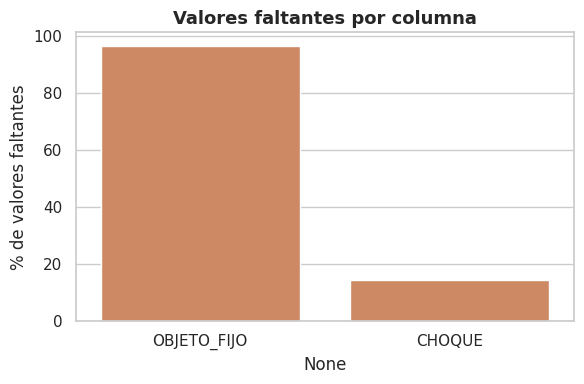

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=missing_df.index, y=missing_df['porcentaje'], ax=ax, color='#DD8452')
ax.set_ylabel('% de valores faltantes')
ax.set_title('Valores faltantes por columna')
plt.tight_layout()
plt.show()

**Solo dos columnas tienen valores faltantes: `CHOQUE` (14,4%) y `OBJETO_FIJO` (96,6%).** Para entender el mecanismo, se cruzan con las variables que condicionan lógicamente su existencia en el formulario IPAT:

- `CHOQUE` describe el subtipo de choque, y **solo aplica cuando `CLASE` = 1 (Choque)**. Para las demás clases de siniestro (atropello, volcamiento, incendio, etc.) el campo no tiene sentido de negocio y por eso queda vacío.
- `OBJETO_FIJO` describe el objeto contra el que se chocó, y **solo aplica cuando `CHOQUE` = 4 (Con objeto fijo)**.

Se verifica esta hipótesis con tablas cruzadas de nulidad:

In [7]:
print("CLASE vs. (CHOQUE es nulo):")
print(pd.crosstab(df['CLASE'], df['CHOQUE'].isna()))
print()
print("CHOQUE vs. (OBJETO_FIJO es nulo):")
print(pd.crosstab(df['CHOQUE'], df['OBJETO_FIJO'].isna(), dropna=False))

CLASE vs. (CHOQUE es nulo):
CHOQUE   False  True 
CLASE                
1       167910      5
2            0  20101
3            0   2615
4            0   4694
5            0     25
6            0    788
7            0     14

CHOQUE vs. (OBJETO_FIJO es nulo):
OBJETO_FIJO  False   True 
CHOQUE                    
1.0              0  160808
2.0              0      28
3.0              0      95
4.0           6689       0
5.0              0     290
NaN              0   28242


**Interpretación y clasificación del mecanismo de faltantes:**

- Para el **99,997%** de los casos, `CHOQUE` es nulo exactamente cuando `CLASE` ≠ 1 (167.910 de 167.915 registros con `CLASE`=1 sí tienen `CHOQUE`; los 28.237 nulos restantes corresponden exactamente a registros con `CLASE`≠1). De igual forma, `OBJETO_FIJO` es nulo exactamente cuando `CHOQUE` ≠ 4. Esto es un **faltante estructural / "no aplica"**: la probabilidad de que el dato falte se explica completamente por el valor observado de otra variable (`CLASE`, `CHOQUE`), no por el valor no observado en sí mismo. En términos de Rubin esto se clasifica como **MAR (Missing At Random)** — no se trata de datos perdidos por error de captura, sino de un campo que **no existía para ese tipo de registro** (el formulario IPAT es condicional/ramificado).
- Existen **5 registros** con `CLASE` = 1 (Choque) pero `CHOQUE` nulo — aquí sí falta un dato que *debería* existir dado que el campo era aplicable. Al ser solo 5 de 196.152 registros (0,003%), se trata de un faltante genuino y aislado, sin relación aparente con ninguna otra variable observada, consistente con **MCAR** (probable error de digitación puntual en el IPAT).

**Tratamiento:**
- Para los faltantes estructurales ("no aplica"), se crea una **categoría explícita `"No aplica"`** en lugar de imputar con la moda, porque imputar aquí introduciría una relación de negocio falsa (por ejemplo, asignar "chocó con vehículo" a un atropello no tiene sentido). Esta es la práctica correcta para MAR estructural en variables categóricas.
- Para los 5 registros MCAR genuinos dentro de `CLASE`=1, se imputa con la **moda condicional** (el subtipo de choque más frecuente dentro de los choques), dado que es un volumen ínfimo y no se justifica descartar el registro completo.

In [8]:
# Mecanismo estructural: crear categoria 'No aplica' (codigo 0) donde el campo no aplica
df['CHOQUE_TRAT'] = df['CHOQUE']
mask_no_aplica_choque = (df['CLASE'] != 1) & (df['CHOQUE'].isna())
df.loc[mask_no_aplica_choque, 'CHOQUE_TRAT'] = 0  # 0 = 'No aplica'

# Faltante genuino MCAR (5 registros): imputar con la moda condicional
moda_choque = df.loc[df['CLASE'] == 1, 'CHOQUE'].mode()[0]
mask_mcar = (df['CLASE'] == 1) & (df['CHOQUE'].isna())
print(f"Registros MCAR genuinos imputados con la moda ({moda_choque}):", mask_mcar.sum())
df.loc[mask_mcar, 'CHOQUE_TRAT'] = moda_choque

df['OBJETO_FIJO_TRAT'] = df['OBJETO_FIJO'].fillna(0)  # 0 = 'No aplica'

print()
print("Faltantes restantes en CHOQUE_TRAT:", df['CHOQUE_TRAT'].isna().sum())
print("Faltantes restantes en OBJETO_FIJO_TRAT:", df['OBJETO_FIJO_TRAT'].isna().sum())

Registros MCAR genuinos imputados con la moda (1.0): 5

Faltantes restantes en CHOQUE_TRAT: 0
Faltantes restantes en OBJETO_FIJO_TRAT: 0


## 2.2 Duplicados

In [9]:
print("Filas completamente duplicadas:", df.duplicated().sum())
print("CODIGO_ACCIDENTE duplicado:", df['CODIGO_ACCIDENTE'].duplicated().sum())

Filas completamente duplicadas: 0
CODIGO_ACCIDENTE duplicado: 0


No se encontraron filas duplicadas ni identificadores de accidente repetidos: `CODIGO_ACCIDENTE` es una llave única para los 196.152 registros. No se requiere ningún tratamiento de duplicados en este dataset.

## 2.3 Valores atípicos (outliers) y categorías raras

Dado que el dataset es mayoritariamente **categórico/codificado** (no tiene variables numéricas continuas tipo precio o edad), el concepto clásico de "outlier" numérico (basado en IQR o z-score) no aplica directamente a las columnas originales. En su lugar, se revisan **categorías con muy baja frecuencia**, para distinguir si son:
- **Genuinas** (categorías reales pero poco comunes, que deben conservarse), o
- **Espurias** (errores de codificación, captura, o valores fuera del dominio esperado, que deberían corregirse o descartarse).

In [10]:
print("Frecuencia de CODIGO_LOCALIDAD (localidades):")
print(df['CODIGO_LOCALIDAD'].value_counts().sort_index())
print()
print("Frecuencia de DISENO_LUGAR:")
print(df['DISENO_LUGAR'].value_counts().sort_index())
print()
print("Frecuencia de CLASE:")
print(df['CLASE'].value_counts().sort_index())

Frecuencia de CODIGO_LOCALIDAD (localidades):
CODIGO_LOCALIDAD
1     19621
2     11502
3      5648
4      5460
5      4026
6      5494
7      9684
8     22282
9     15598
10    19777
11    17759
12    10467
13    10317
14     6622
15     3982
16    13876
17     1003
18     5111
19     7916
20        7
Name: count, dtype: int64

Frecuencia de DISENO_LUGAR:
DISENO_LUGAR
1     150989
2      38209
3         83
4       1183
5        577
6        302
7       2105
8        358
9          1
10      1962
11       341
12        13
13        29
Name: count, dtype: int64

Frecuencia de CLASE:
CLASE
1    167915
2     20101
3      2615
4      4694
5        25
6       788
7        14
Name: count, dtype: int64


**Análisis de las categorías menos frecuentes:**

- `CODIGO_LOCALIDAD` = 20 (Sumapaz) tiene solo **7 registros**. Esto es **genuino**: Sumapaz es la localidad rural de Bogotá, con población y tráfico vehicular mínimos, por lo que un número bajo de siniestros es consistente con la realidad — se conserva.
- `DISENO_LUGAR` = 9 (Vía troncal, 1 registro) y = 12 (Pontón, 13 registros) son **genuinos pero raros**: hay muy pocos siniestros justo en esos tipos específicos de infraestructura vial — se conservan como categorías válidas.
- `CLASE` = 5 (Incendio, 25 registros) y `CLASE` = 7 (Autolesión, 14 registros) son eventos genuinamente raros en la vía pública — se conservan.

No se encontraron valores fuera del dominio esperado de cada código (`GRAVEDAD` solo toma valores {1,2,3}, `CODIGO_LOCALIDAD` solo toma valores {1,...,20}, `DISENO_LUGAR` solo toma valores {1,...,13}), por lo que **no hay evidencia de categorías espurias** (errores de captura) en las variables codificadas. También se validó que `FECHA` está en el rango esperado (2015-2020, sin fechas futuras ni anteriores a la existencia del sistema) y que `HORA` solo contiene horas válidas (00:00:00 a 23:59:59):

In [11]:
print("Rango de fechas:", df['FECHA'].min().date(), "a", df['FECHA'].max().date())
print("Valores unicos fuera de rango en GRAVEDAD:", set(df['GRAVEDAD'].unique()) - {1,2,3})
print("Valores unicos fuera de rango en CODIGO_LOCALIDAD:", set(df['CODIGO_LOCALIDAD'].unique()) - set(range(1,21)))
print("Valores unicos fuera de rango en DISENO_LUGAR:", set(df['DISENO_LUGAR'].unique()) - set(range(1,14)))
horas_dt = pd.to_datetime(df['HORA'], format='%H:%M:%S', errors='coerce')
print("Horas que no pudieron interpretarse como HH:MM:SS:", horas_dt.isna().sum())

Rango de fechas: 2015-01-01 a 2020-12-31
Valores unicos fuera de rango en GRAVEDAD: set()
Valores unicos fuera de rango en CODIGO_LOCALIDAD: set()
Valores unicos fuera de rango en DISENO_LUGAR: set()
Horas que no pudieron interpretarse como HH:MM:SS: 0


---
# 3. Transformación de Datos

Esta sección cubre: (a) ingeniería de variables nuevas a partir de fecha/hora/dirección, (b) construcción de la **variable objetivo nueva** para la tarea predictiva, (c) codificación de variables categóricas, y (d) escalado y verificación de asimetría, cada una justificada según el algoritmo que la usará.

## 3.1 Ingeniería de variables nuevas (feature engineering)

A partir de `FECHA`, `HORA` y `DIRECCION` se derivan variables nuevas que no existen en el dataset original y que son más informativas para clustering y clasificación que los campos crudos:

- `HORA_INT`, `DIA_SEMANA_NUM`, `MES`, `ANIO`: componentes numéricos de fecha/hora.
- `ES_FIN_DE_SEMANA`: indicador binario (sábado/domingo).
- `FRANJA_HORARIA`: Madrugada (0-5h), Mañana (6-11h), Tarde (12-17h), Noche (18-23h).
- `ES_HORA_PICO`: indicador binario de hora pico (6-8h y 16-19h), horario de mayor congestión vehicular en Bogotá.
- `TIPO_VIA`: extraída de `DIRECCION` (texto libre con ~92.500 valores únicos, demasiado disperso para usar directamente en un modelo) mediante el prefijo de la nomenclatura vial oficial de Bogotá (KR/CR=Carrera, CL=Calle, AV/AK/AC=Avenida, DG=Diagonal, TV=Transversal). Esto **reduce una variable de altísima cardinalidad a una variable categórica útil de pocas categorías**, resolviendo un problema real de calidad de datos (cardinalidad inmanejable) mediante ingeniería de variables en vez de descartar la información de la dirección.

In [12]:
# --- Variables temporales ---
df['HORA_INT'] = pd.to_datetime(df['HORA'], format='%H:%M:%S').dt.hour
df['DIA_SEMANA_NUM'] = df['FECHA'].dt.dayofweek          # 0=lunes ... 6=domingo
df['MES'] = df['FECHA'].dt.month
df['ANIO'] = df['FECHA'].dt.year
df['ES_FIN_DE_SEMANA'] = (df['DIA_SEMANA_NUM'] >= 5).astype(int)

def franja_horaria(h):
    if 0 <= h < 6:
        return 'Madrugada'
    elif 6 <= h < 12:
        return 'Manana'
    elif 12 <= h < 18:
        return 'Tarde'
    else:
        return 'Noche'

df['FRANJA_HORARIA'] = df['HORA_INT'].apply(franja_horaria)
df['ES_HORA_PICO'] = df['HORA_INT'].isin([6,7,8,16,17,18,19]).astype(int)

dias_es = {0:'Lunes',1:'Martes',2:'Miercoles',3:'Jueves',4:'Viernes',5:'Sabado',6:'Domingo'}
df['DIA_SEMANA_NOM'] = df['DIA_SEMANA_NUM'].map(dias_es)

# --- Tipo de via a partir de la direccion (reduce cardinalidad ~92.500 -> 6) ---
def tipo_via(direccion):
    d = str(direccion).strip().upper()
    if d.startswith('AK') or d.startswith('AC') or d.startswith('AV'):
        return 'Avenida'
    elif d.startswith('KR') or d.startswith('CR'):
        return 'Carrera'
    elif d.startswith('CL'):
        return 'Calle'
    elif d.startswith('DG'):
        return 'Diagonal'
    elif d.startswith('TV'):
        return 'Transversal'
    else:
        return 'Otro'

df['TIPO_VIA'] = df['DIRECCION'].apply(tipo_via)

print("Cardinalidad original de DIRECCION:", df['DIRECCION'].nunique())
print("Cardinalidad de TIPO_VIA (nueva):", df['TIPO_VIA'].nunique())
df[['FECHA','HORA','HORA_INT','DIA_SEMANA_NOM','ES_FIN_DE_SEMANA','FRANJA_HORARIA','ES_HORA_PICO','TIPO_VIA']].head()

Cardinalidad original de DIRECCION: 92518
Cardinalidad de TIPO_VIA (nueva): 6


,FECHA,HORA,HORA_INT,DIA_SEMANA_NOM,ES_FIN_DE_SEMANA,FRANJA_HORARIA,ES_HORA_PICO,TIPO_VIA
0,2015-01-01,01:05:00,1,Jueves,0,Madrugada,0,Carrera
1,2015-01-01,05:50:00,5,Jueves,0,Madrugada,0,Avenida
2,2015-01-01,07:15:00,7,Jueves,0,Manana,1,Carrera
3,2015-01-01,09:30:00,9,Jueves,0,Manana,0,Carrera
4,2015-01-01,09:45:00,9,Jueves,0,Manana,0,Calle


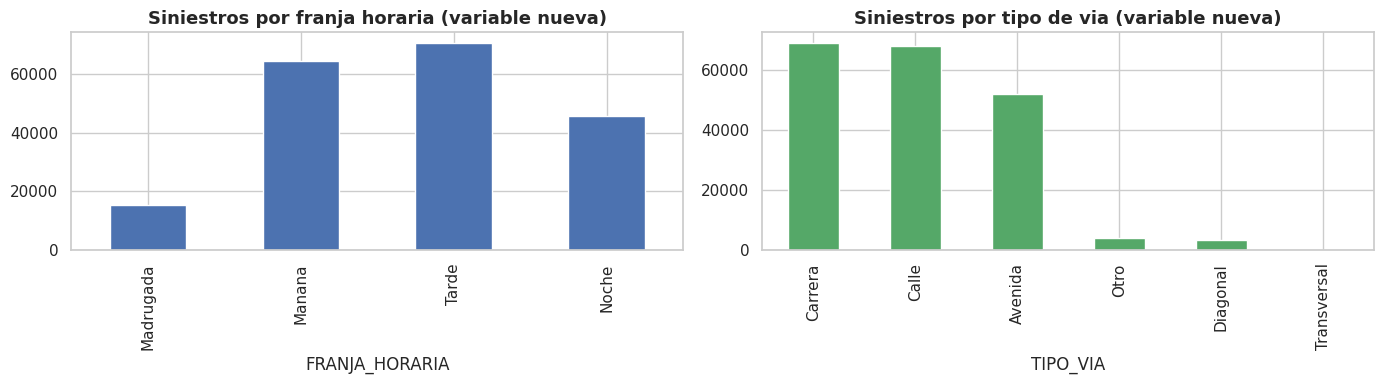

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
df['FRANJA_HORARIA'].value_counts().loc[['Madrugada','Manana','Tarde','Noche']].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Siniestros por franja horaria (variable nueva)')
df['TIPO_VIA'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Siniestros por tipo de via (variable nueva)')
plt.tight_layout()
plt.show()

## 3.2 Variable objetivo nueva para la tarea predictiva

El dataset original **no trae una variable de clasificación binaria lista para modelar**. La variable más cercana, `GRAVEDAD`, ya viene con 3 clases (con muertos / con heridos / solo daños); usarla directamente como target no cumple con el requisito de construir una variable nueva, y además una variable de 3 clases con la clase "con muertos" extremadamente minoritaria (1,5%) sería muy difícil de modelar de forma robusta.

Por eso, para la tarea predictiva se construye una **variable nueva**, `SINIESTRO_CON_VICTIMAS`, que agrupa con criterio de negocio las categorías de `GRAVEDAD` en dos clases:

$$\text{SINIESTRO\_CON\_VICTIMAS} = \begin{cases} 1 & \text{si GRAVEDAD} \in \{\text{Con muertos, Con heridos}\} \\ 0 & \text{si GRAVEDAD} = \text{Solo daños materiales} \end{cases}$$

**Justificación de negocio:** desde la perspectiva de priorización de recursos de la SDM, la distinción operativa más relevante no son los 3 niveles de gravedad por separado, sino **si hubo o no personas afectadas físicamente**, ya que eso determina la necesidad de atención prehospitalaria, investigación más profunda del siniestro y, sobre todo, es el indicador que más le importa a la política pública de seguridad vial (reducir víctimas, no solo reducir choques). Convertirlo en un problema binario también permite usar métricas de clasificación estándar (precisión, recall, F1, AUC-ROC) de forma robusta e interpretable para una audiencia no técnica.

SINIESTRO_CON_VICTIMAS
0    127919
1     68233
Name: count, dtype: int64

Proporcion de siniestros con victimas: 34.8 %


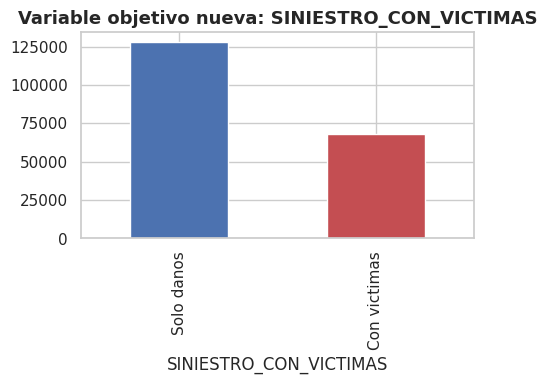

In [14]:
df['SINIESTRO_CON_VICTIMAS'] = df['GRAVEDAD'].isin([1, 2]).astype(int)

print(df['SINIESTRO_CON_VICTIMAS'].value_counts())
print()
print("Proporcion de siniestros con victimas:", round(df['SINIESTRO_CON_VICTIMAS'].mean()*100,1), "%")

fig, ax = plt.subplots(figsize=(5,4))
df['SINIESTRO_CON_VICTIMAS'].value_counts().rename({0:'Solo danos',1:'Con victimas'}).plot(kind='bar', ax=ax, color=['#4C72B0','#C44E52'])
ax.set_title('Variable objetivo nueva: SINIESTRO_CON_VICTIMAS')
plt.tight_layout()
plt.show()

## 3.3 Codificación de variables categóricas

Las variables categóricas nominales que se usarán en clustering y clasificación son: `CODIGO_LOCALIDAD` (20 categorías), `CLASE` (7), `CHOQUE_TRAT` (6, incluyendo "No aplica"), `DISENO_LUGAR` (13), `TIPO_VIA` (6) y `FRANJA_HORARIA` (4). Ninguna tiene un orden natural entre sus categorías (no son ordinales), por lo que la codificación adecuada es **One-Hot Encoding**: codificar variables nominales sin orden como enteros arbitrarios (Label Encoding) introduciría una relación de magnitud falsa que confundiría tanto a algoritmos basados en distancia (KMeans) como a modelos lineales (Regresión Logística). La cardinalidad de todas estas variables es moderada (máximo 20 categorías), por lo que One-Hot no genera una dimensionalidad excesiva, y es compatible tanto con modelos lineales/basados en distancia como con modelos de árboles.

`GRAVEDAD` sí es ordinal por naturaleza (Solo daños < Con heridos < Con muertos), pero **no se usa como predictor** (se usa únicamente para construir la variable objetivo en la sección 3.2), por lo que no requiere codificación ordinal en este proyecto.

La codificación se aplica **dentro de un `Pipeline`/`ColumnTransformer`** más adelante (secciones 4 y 5), ajustándola únicamente sobre los datos de entrenamiento para evitar fuga de información hacia el conjunto de prueba.

## 3.4 Escalado

Las variables numéricas (`HORA_INT`, `MES`, `ANIO`, `DIA_SEMANA_NUM`) tienen escalas distintas (por ejemplo, `ANIO` ronda 2015-2020 mientras que `DIA_SEMANA_NUM` va de 0 a 6). El escalado es indispensable para **KMeans** (basado en distancia euclidiana: sin escalar, `ANIO` dominaría por completo la distancia frente a variables acotadas 0-6) y beneficia también a la **Regresión Logística** (mejora la convergencia numérica y la interpretabilidad de los coeficientes). No es estrictamente necesario para los modelos de árboles (Random Forest, HistGradientBoosting, invariantes a escala monótona), pero tampoco los perjudica, así que se aplica de forma uniforme dentro del mismo pipeline. Se usa `StandardScaler` (media 0, desviación estándar 1), ajustado **solo con los datos de entrenamiento** (nunca antes de separar train/test, para evitar fuga de información).

## 3.5 Verificación de asimetría (skewness)

Antes de decidir si se necesitan transformaciones matemáticas (log, Box-Cox, etc.), se revisa la asimetría de las variables numéricas:

In [15]:
from scipy.stats import skew

num_cols_check = ['HORA_INT','MES','ANIO','DIA_SEMANA_NUM']
for c in num_cols_check:
    print(f"{c}: skewness = {skew(df[c]):.3f}")

HORA_INT: skewness = -0.138
MES: skewness = -0.043
ANIO: skewness = 0.033
DIA_SEMANA_NUM: skewness = 0.022


Todas las variables numéricas derivadas de fecha/hora son **acotadas y aproximadamente uniformes** (horas 0-23, meses 1-12, día de la semana 0-6), con valores de asimetría cercanos a 0 (< |0.5|). No hay colas largas ni concentración extrema en un rango, por lo que **no se requieren transformaciones matemáticas** (log, raíz cuadrada, Box-Cox) en este dataset — a diferencia de variables económicas típicas (ingresos, precios), las variables temporales cíclicas no presentan el patrón de asimetría que estas transformaciones buscan corregir.

---
# 4. Tarea Descriptiva: Clustering

**Objetivo de negocio:** segmentar los siniestros viales en perfiles característicos según su **contexto** (dónde, cuándo, en qué tipo de vía y de qué clase), para que la SDM pueda priorizar intervenciones de infraestructura y campañas de prevención por segmento, en vez de aplicar una única estrategia genérica a toda la ciudad.

## 4.1 Selección de variables

Se seleccionan variables que describen el **contexto físico y temporal** del siniestro (no su resultado/gravedad, para que los clusters reflejen circunstancias accionables, no consecuencias):

- `CODIGO_LOCALIDAD` (dónde)
- `CLASE` (qué tipo de siniestro)
- `DISENO_LUGAR` (en qué tipo de infraestructura)
- `TIPO_VIA` (variable nueva: tipo de vía)
- `FRANJA_HORARIA` (variable nueva: momento del día)
- `ES_FIN_DE_SEMANA` (variable nueva: día laboral vs. fin de semana)

## 4.2 Codificación, escalado y reducción de dimensionalidad

Se codifican las variables categóricas con One-Hot y se escala `ES_FIN_DE_SEMANA`. Como el One-Hot genera varias decenas de columnas dispersas (~50), se aplica **PCA** para condensar la información en componentes principales antes de aplicar KMeans — esto mitiga el efecto de la "maldición de la dimensionalidad" en distancias euclidianas con muchas variables dummy dispersas, mejora la calidad geométrica de los clusters y acelera el cómputo.

In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

clu_cat_cols = ['CODIGO_LOCALIDAD', 'CLASE', 'DISENO_LUGAR', 'TIPO_VIA', 'FRANJA_HORARIA']
clu_num_cols = ['ES_FIN_DE_SEMANA']

Xc = df[clu_cat_cols + clu_num_cols].copy()
for c in clu_cat_cols:
    Xc[c] = Xc[c].astype(str)

pre_cluster = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), clu_cat_cols),
    ('num', StandardScaler(), clu_num_cols)
])

Xc_encoded = pre_cluster.fit_transform(Xc)
Xc_encoded = Xc_encoded.toarray() if hasattr(Xc_encoded, 'toarray') else Xc_encoded
print("Dimensiones tras codificar (One-Hot + escalado):", Xc_encoded.shape)

pca = PCA(n_components=0.85, random_state=RANDOM_STATE)  # conservar 85% de la varianza
Xc_pca = pca.fit_transform(Xc_encoded)
print(f"Dimensiones tras PCA: {Xc_pca.shape}  (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})")

Dimensiones tras codificar (One-Hot + escalado): (196152, 51)
Dimensiones tras PCA: (196152, 14)  (varianza explicada: 85.9%)


## 4.3 Elección del número de clusters (K)

Se usan **dos criterios complementarios**: el método del codo (inercia intra-cluster) y el Silhouette Score. Dado el tamaño del dataset (196.152 registros), evaluar múltiples valores de K sobre el 100% de los datos sería computacionalmente costoso; se usa una **muestra aleatoria de 15.000 registros** para explorar K (práctica estándar para acelerar la exploración en datasets grandes), y luego se ajusta el modelo final sobre esa muestra y se asignan clusters a **todos** los registros.

In [17]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(Xc_pca), size=15000, replace=False)
Xc_sample = Xc_pca[sample_idx]

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xc_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(Xc_sample, km.labels_, sample_size=5000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f"K={k}  inercia={km.inertia_:,.0f}  silhouette={sil:.3f}")

K=2  inercia=35,617  silhouette=0.329


K=3  inercia=31,978  silhouette=0.185


K=4  inercia=28,564  silhouette=0.222


K=5  inercia=26,548  silhouette=0.224


K=6  inercia=25,295  silhouette=0.195


K=7  inercia=24,287  silhouette=0.179


K=8  inercia=23,264  silhouette=0.175


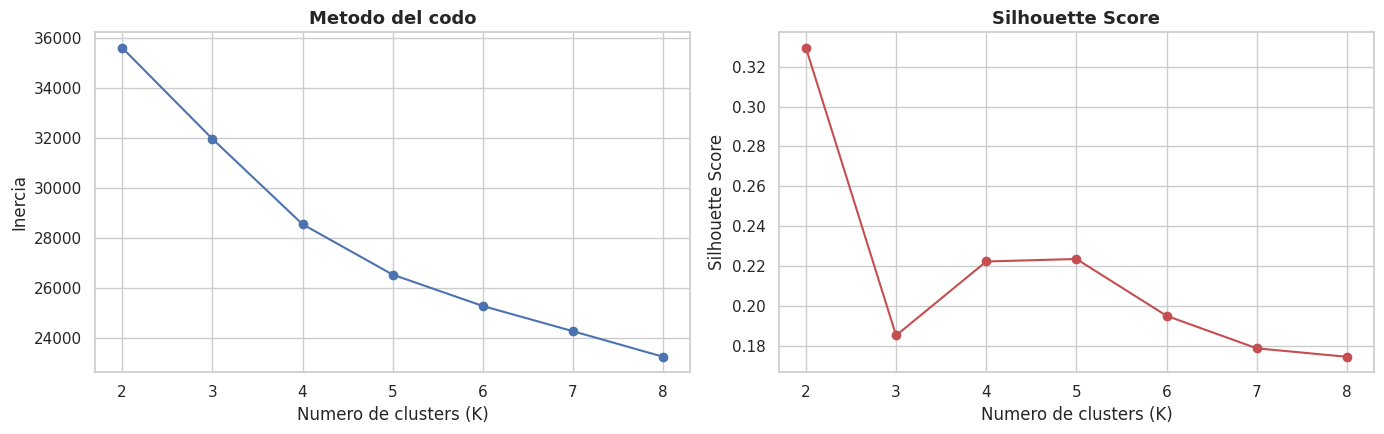

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('Numero de clusters (K)')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#C44E52')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Numero de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

**Interpretación de los dos criterios (valores obtenidos en esta corrida):**

| K | Inercia | Δ Inercia | Silhouette |
|---|---|---|---|
| 2 | 35.617 | — | 0.329 |
| 3 | 31.978 | -3.639 | 0.185 |
| 4 | 28.564 | -3.414 | 0.222 |
| 5 | 26.548 | -2.016 | 0.224 |
| 6 | 25.295 | -1.253 | 0.195 |
| 7 | 24.287 | -1.008 | 0.179 |
| 8 | 23.264 | -1.023 | 0.175 |

- **Método del codo:** la caída de inercia es continua, pero la *tasa* de caída se reduce claramente a partir de K=4→5 (de -3.414 a -2.016, casi la mitad), y sigue moderándose después. Ese es el punto donde agregar más clusters deja de aportar una reducción de inercia proporcional al costo de interpretabilidad — el "codo" práctico está en K=4-5.
- **Silhouette Score:** el máximo global está en K=2 (0.329), pero una partición en solo 2 grupos es demasiado genérica para ser accionable (prácticamente separa "fin de semana" de "entre semana"). Después de la caída en K=3, el score se recupera y forma un **segundo máximo local en K=4-5** (0.222 y 0.224, prácticamente empatados), tras el cual vuelve a bajar de forma sostenida.

Combinando ambos criterios (el codo se estabiliza en K=4-5, y el silhouette tiene ahí su segundo mejor valor) se elige **K=4**: mejora sustancialmente la cohesión frente a K=2/3 sin perder la ventaja del segundo máximo de silhouette, y produce un número de segmentos suficientemente pequeño para ser interpretable y accionable por el equipo de seguridad vial (a diferencia de K=7-8, que fragmentaría en exceso la estrategia de intervención).

In [19]:
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10).fit(Xc_sample)
df['CLUSTER'] = kmeans_final.predict(Xc_pca)  # se asigna cluster a los 196.152 registros

print(df['CLUSTER'].value_counts().sort_index())

CLUSTER
0    42439
1    52663
2    48945
3    52105
Name: count, dtype: int64


## 4.4 Interpretación de negocio de cada segmento

Para interpretar los clusters se decodifican las variables categóricas a etiquetas legibles (usando la hoja `DICCIONARIO`) y se describe cada segmento con sus variables más frecuentes.

In [20]:
localidad_map = {1:'Usaquen',2:'Chapinero',3:'Santa Fe',4:'San Cristobal',5:'Usme',6:'Tunjuelito',
                 7:'Bosa',8:'Kennedy',9:'Fontibon',10:'Engativa',11:'Suba',12:'Barrios Unidos',
                 13:'Teusaquillo',14:'Los Martires',15:'Antonio Narino',16:'Puente Aranda',
                 17:'La Candelaria',18:'Rafael Uribe Uribe',19:'Ciudad Bolivar',20:'Sumapaz'}
clase_map = {1:'Choque',2:'Atropello',3:'Volcamiento',4:'Caida de ocupante',5:'Incendio',6:'Otro',7:'Autolesion'}
diseno_map = {1:'Tramo de via',2:'Interseccion',3:'Via peatonal',4:'Paso elevado',5:'Paso inferior',
              6:'Paso a nivel',7:'Glorieta',8:'Puente',9:'Via troncal',10:'Lote/predio',
              11:'Ciclorruta',12:'Ponton',13:'Tunel'}

df['LOCALIDAD_NOM'] = df['CODIGO_LOCALIDAD'].map(localidad_map)
df['CLASE_NOM'] = df['CLASE'].map(clase_map)
df['DISENO_NOM'] = df['DISENO_LUGAR'].map(diseno_map)

resumen_clusters = df.groupby('CLUSTER').agg(
    n_siniestros=('CODIGO_ACCIDENTE','count'),
    pct_fin_de_semana=('ES_FIN_DE_SEMANA','mean'),
    pct_con_victimas=('SINIESTRO_CON_VICTIMAS','mean'),
    localidad_top=('LOCALIDAD_NOM', lambda s: s.value_counts().idxmax()),
    clase_top=('CLASE_NOM', lambda s: s.value_counts().idxmax()),
    tipo_via_top=('TIPO_VIA', lambda s: s.value_counts().idxmax()),
    franja_top=('FRANJA_HORARIA', lambda s: s.value_counts().idxmax()),
).round(3)
resumen_clusters

,n_siniestros,pct_fin_de_semana,pct_con_victimas,localidad_top,clase_top,tipo_via_top,franja_top
CLUSTER,,,,,,,
0,42439,0.0,0.345,Kennedy,Choque,Avenida,Manana
1,52663,0.0,0.337,Engativa,Choque,Calle,Tarde
2,48945,1.0,0.357,Kennedy,Choque,Carrera,Tarde
3,52105,0.0,0.352,Usaquen,Choque,Carrera,Tarde


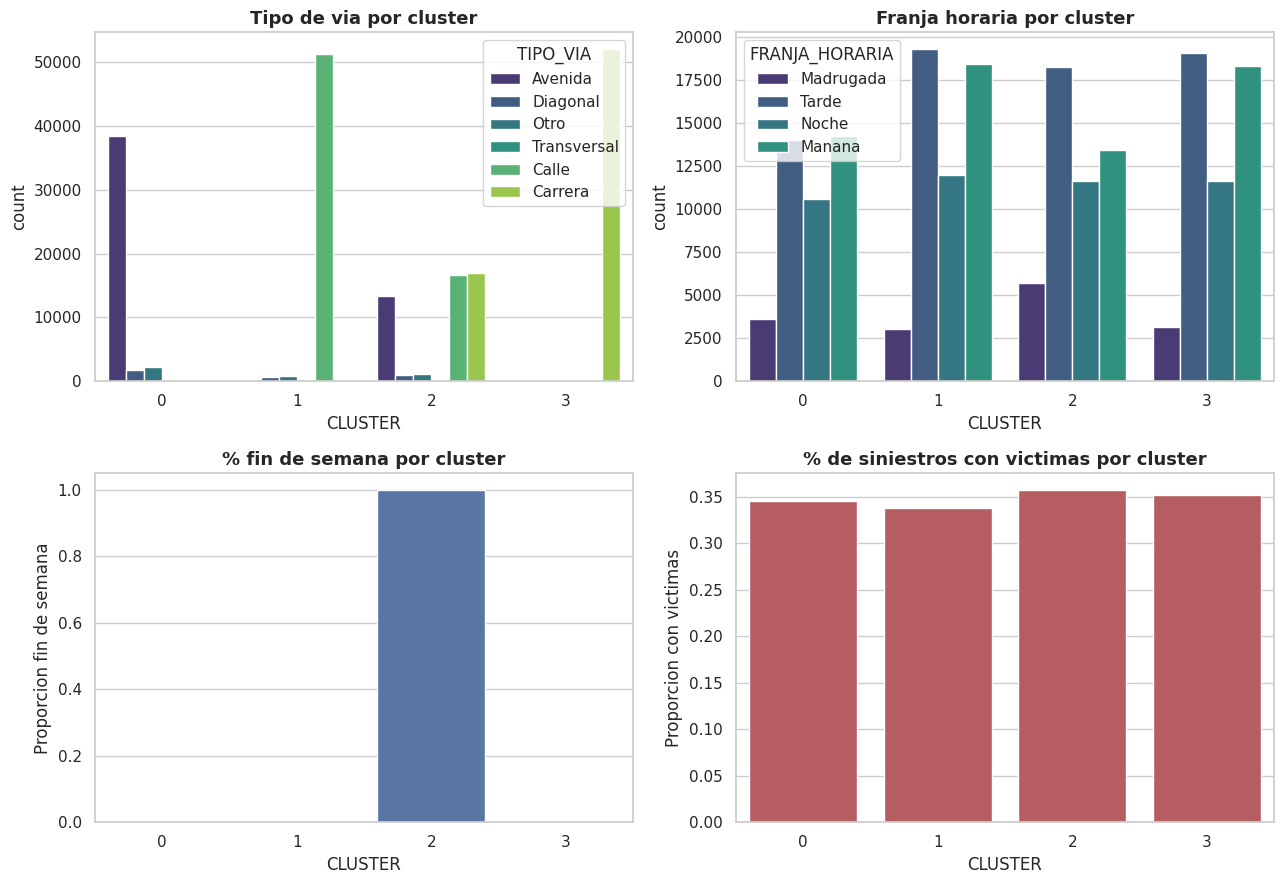

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))

sns.countplot(data=df, x='CLUSTER', hue='TIPO_VIA', ax=axes[0,0])
axes[0,0].set_title('Tipo de via por cluster')

sns.countplot(data=df, x='CLUSTER', hue='FRANJA_HORARIA', ax=axes[0,1])
axes[0,1].set_title('Franja horaria por cluster')

sns.barplot(data=df, x='CLUSTER', y='ES_FIN_DE_SEMANA', ax=axes[1,0], color='#4C72B0', errorbar=None)
axes[1,0].set_title('% fin de semana por cluster')
axes[1,0].set_ylabel('Proporcion fin de semana')

sns.barplot(data=df, x='CLUSTER', y='SINIESTRO_CON_VICTIMAS', ax=axes[1,1], color='#C44E52', errorbar=None)
axes[1,1].set_title('% de siniestros con victimas por cluster')
axes[1,1].set_ylabel('Proporcion con victimas')

plt.tight_layout()
plt.show()

**Perfiles de negocio resultantes (interpretación):**

| Cluster | n | % fin de semana | % con víctimas | Localidad top | Tipo de vía top | Franja top |
|---|---|---|---|---|---|---|
| 0 | 42.439 | 0% | 34,5% | Kennedy | Avenida | Mañana |
| 1 | 52.663 | 0% | 33,7% | Engativá | Calle | Tarde |
| 2 | 48.945 | 100% | 35,7% | Kennedy | Carrera | Tarde |
| 3 | 52.105 | 0% | 35,2% | Usaquén | Carrera | Tarde |

- **Cluster 0 — "Avenidas entre semana en la mañana":** siniestros concentrados en **avenidas** (vías arteriales de alta velocidad), en horario de la mañana, entre semana, con predominio en Kennedy. Recomendación: mantenimiento de señalización y controles de velocidad en corredores troncales, reforzados en la franja de la mañana (hora pico de entrada laboral).
- **Cluster 1 — "Malla vial local entre semana":** siniestros en **calles** locales/barriales, en horario de la tarde, entre semana, con predominio en Engativá. Es el segmento con la **menor** tasa de víctimas (33,7%). Recomendación: pacificación del tráfico local y mejoras de visibilidad en cruces de barrio, con prioridad más baja que los demás segmentos.
- **Cluster 2 — "Fin de semana":** el único segmento con **100% de siniestros en fin de semana**, concentrado en carreras, con predominio en Kennedy, y la **mayor tasa de siniestros con víctimas** de los cuatro clusters (35,7%). Recomendación: es el segmento prioritario para controles de alcoholemia y velocidad en horario de fin de semana.
- **Cluster 3 — "Carreras entre semana en el norte":** siniestros concentrados en **carreras**, en horario de la tarde, entre semana, con alta presencia en Usaquén (localidades del norte/centro-oriente). Recomendación: revisión de intersecciones semaforizadas sobre estas carreras.

La variable que más diferencia geométrica y temporalmente los clusters es el **tipo de vía** (avenida/calle/carrera) combinado con el **carácter laboral/fin de semana** — la clase de siniestro (`clase_top`) no diferencia los clusters porque "Choque" domina el 85,6% de todos los registros del dataset, independientemente del segmento.

En cuanto a la gravedad, las diferencias entre clusters son **reales pero moderadas** (33,7% a 35,7% de siniestros con víctimas): el contexto físico/temporal por sí solo no separa dramáticamente el riesgo de víctimas — es un hallazgo relevante que se retoma y profundiza en la sección 7, donde se cruza cada cluster con la probabilidad predicha por el modelo de clasificación (que sí logra una discriminación bastante mayor usando, además del contexto, la clase de siniestro y el tipo de choque).

---
# 5. Tarea Predictiva: Modelos de Clasificación

**Objetivo de negocio:** predecir la variable nueva `SINIESTRO_CON_VICTIMAS` (1 = con heridos o muertos, 0 = solo daños materiales) a partir de las **circunstancias** del siniestro (localidad, clase, tipo de choque, diseño de la vía, tipo de vía y contexto temporal), para identificar qué combinaciones de circunstancias están asociadas a un mayor riesgo de que existan víctimas, e informar decisiones de infraestructura y de política pública de prevención.

## 5.1 Variables predictoras

Se excluyen deliberadamente de los predictores: `GRAVEDAD` (porque define el objetivo — usarla causaría fuga de información directa), `CODIGO_ACCIDENTE` (identificador sin valor predictivo), `CLUSTER` (variable derivada del análisis descriptivo, se usa después solo para el análisis de integración de la sección 7, no como predictor) y `DIRECCION`/`FECHA`/`HORA` en su forma cruda (ya representadas por las variables de ingeniería `TIPO_VIA` y las variables temporales).

In [22]:
cat_cols = ['CODIGO_LOCALIDAD', 'CLASE', 'CHOQUE_TRAT', 'DISENO_LUGAR', 'TIPO_VIA', 'FRANJA_HORARIA']
num_cols = ['HORA_INT', 'MES', 'ANIO', 'DIA_SEMANA_NUM', 'ES_FIN_DE_SEMANA', 'ES_HORA_PICO']

X = df[cat_cols + num_cols].copy()
for c in cat_cols:
    X[c] = X[c].astype(str)
y = df['SINIESTRO_CON_VICTIMAS']

print("Variables predictoras:", cat_cols + num_cols)
print("Balance de clases:")
print(y.value_counts(normalize=True).round(3))

Variables predictoras: ['CODIGO_LOCALIDAD', 'CLASE', 'CHOQUE_TRAT', 'DISENO_LUGAR', 'TIPO_VIA', 'FRANJA_HORARIA', 'HORA_INT', 'MES', 'ANIO', 'DIA_SEMANA_NUM', 'ES_FIN_DE_SEMANA', 'ES_HORA_PICO']
Balance de clases:
SINIESTRO_CON_VICTIMAS
0    0.652
1    0.348
Name: proportion, dtype: float64


## 5.2 Separación train/test

Se separa **antes** de escalar/codificar, para evitar fuga de información (el `ColumnTransformer` se ajusta únicamente con datos de entrenamiento, dentro de un `Pipeline`). Se usa `stratify=y` para conservar la proporción de clases en ambos conjuntos.

In [23]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)
print("Balance train:", y_train.mean().round(3), " Balance test:", y_test.mean().round(3))

Entrenamiento: (156921, 12)  Prueba: (39231, 12)
Balance train: 0.348  Balance test: 0.348


## 5.3 Comparación de 3 algoritmos con validación cruzada

Se comparan tres algoritmos de clasificación de naturaleza distinta, para cubrir un modelo lineal, uno de ensamble tipo *bagging* y uno de ensamble tipo *boosting*:

1. **Regresión Logística** — modelo lineal, rápido, altamente interpretable (coeficientes), buen punto de referencia (*baseline*).
2. **Random Forest** — ensamble de árboles (bagging), captura relaciones no lineales e interacciones entre variables categóricas sin necesidad de especificarlas manualmente.
3. **HistGradientBoosting** — ensamble de árboles por *boosting*, eficiente en datasets grandes (~200K filas) y habitualmente el de mejor desempeño predictivo entre los tres.

Cada modelo se evalúa con **validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento**, usando F1 y AUC-ROC como métricas (más informativas que accuracy dado el desbalance moderado de clases, ~65/35).

In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, n_jobs=-1,
                                             class_weight='balanced', random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', modelo)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=['f1', 'roc_auc', 'accuracy'], n_jobs=-1)
    resultados_cv[nombre] = {
        'F1 (CV)': scores['test_f1'].mean(),
        'AUC-ROC (CV)': scores['test_roc_auc'].mean(),
        'Accuracy (CV)': scores['test_accuracy'].mean(),
    }
    print(f"{nombre}: F1={scores['test_f1'].mean():.3f} (+/-{scores['test_f1'].std():.3f})  "
          f"AUC={scores['test_roc_auc'].mean():.3f}  Acc={scores['test_accuracy'].mean():.3f}")

cv_df = pd.DataFrame(resultados_cv).T
cv_df

Regresion Logistica: F1=0.632 (+/-0.004)  AUC=0.797  Acc=0.769


Random Forest: F1=0.632 (+/-0.004)  AUC=0.803  Acc=0.780


HistGradientBoosting: F1=0.597 (+/-0.002)  AUC=0.808  Acc=0.792


,F1 (CV),AUC-ROC (CV),Accuracy (CV)
Regresion Logistica,0.631866,0.796880,0.768699
Random Forest,0.632231,0.803190,0.779947
HistGradientBoosting,0.597398,0.808213,0.791609


## 5.4 Entrenamiento final y evaluación en el conjunto de prueba

Se re-entrena cada modelo con **todo** el conjunto de entrenamiento y se evalúa sobre el conjunto de prueba (nunca antes visto), usando las métricas apropiadas para clasificación binaria: **accuracy, precisión, recall, F1 y AUC-ROC**.

In [25]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report, confusion_matrix, roc_curve)

pipelines_finales = {}
resultados_test = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pipelines_finales[nombre] = pipe

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    resultados_test[nombre] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'AUC-ROC': roc_auc_score(y_test, proba),
    }

test_df = pd.DataFrame(resultados_test).T.round(3)
test_df

,Accuracy,Precision,Recall,F1,AUC-ROC
Regresion Logistica,0.767,0.702,0.572,0.630,0.798
Random Forest,0.781,0.756,0.547,0.634,0.804
HistGradientBoosting,0.795,0.916,0.452,0.606,0.809


## 5.5 Selección del mejor modelo

Se selecciona el modelo con **mayor AUC-ROC** en el conjunto de prueba, por ser la métrica más robusta al desbalance de clases y la que mejor resume la capacidad global de discriminación del modelo (independiente de un umbral de decisión particular).

In [26]:
mejor_modelo_nombre = test_df['AUC-ROC'].idxmax()
mejor_pipeline = pipelines_finales[mejor_modelo_nombre]
print(f"Mejor modelo segun AUC-ROC en prueba: {mejor_modelo_nombre}")
print(test_df.loc[mejor_modelo_nombre])

Mejor modelo segun AUC-ROC en prueba: HistGradientBoosting
Accuracy     0.795
Precision    0.916
Recall       0.452
F1           0.606
AUC-ROC      0.809
Name: HistGradientBoosting, dtype: float64


---
# 6. Evaluación y Diagnóstico

## 6.1 Matriz de confusión y curvas ROC

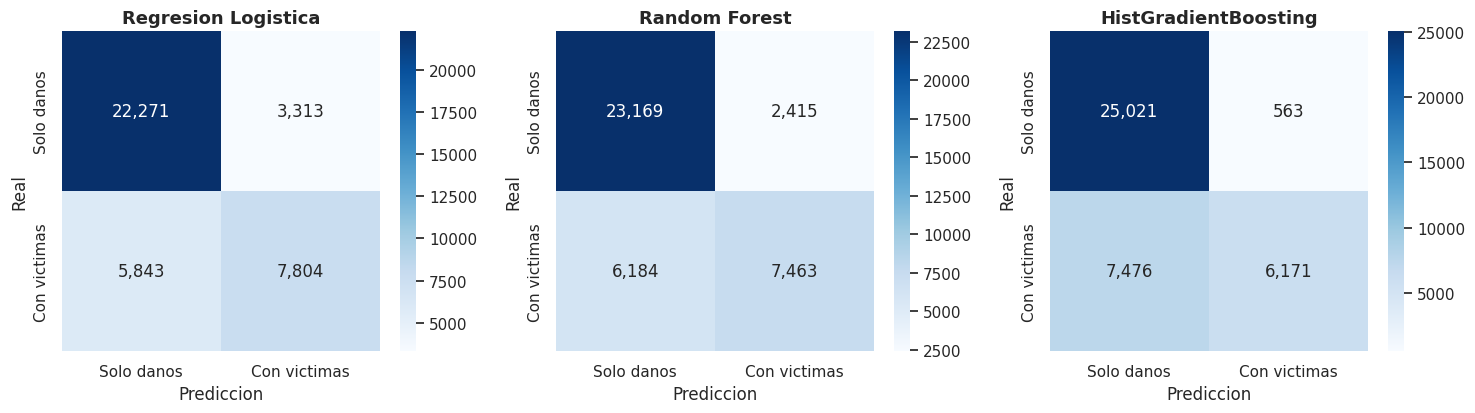

In [27]:
fig, axes = plt.subplots(1, len(modelos), figsize=(5*len(modelos), 4.3))
for ax, (nombre, pipe) in zip(axes, pipelines_finales.items()):
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Solo danos','Con victimas'], yticklabels=['Solo danos','Con victimas'])
    ax.set_title(nombre)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

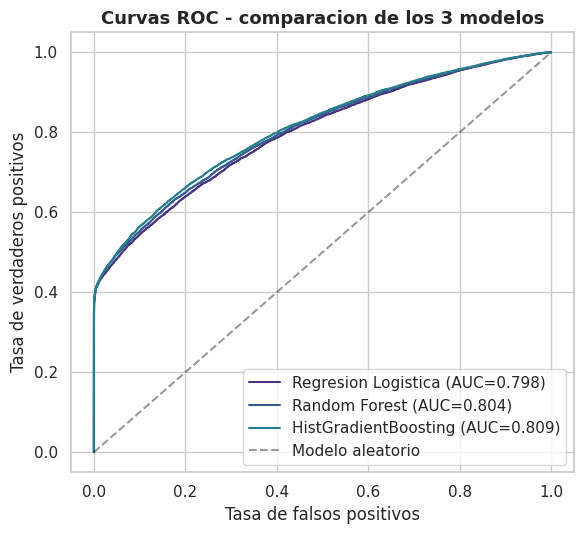

In [28]:
fig, ax = plt.subplots(figsize=(6,5.5))
for nombre, pipe in pipelines_finales.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Modelo aleatorio')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC - comparacion de los 3 modelos')
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
print(f"Reporte de clasificacion detallado - {mejor_modelo_nombre}\n")
pred_mejor = mejor_pipeline.predict(X_test)
print(classification_report(y_test, pred_mejor, target_names=['Solo danos','Con victimas']))

Reporte de clasificacion detallado - HistGradientBoosting



              precision    recall  f1-score   support

  Solo danos       0.77      0.98      0.86     25584
Con victimas       0.92      0.45      0.61     13647

    accuracy                           0.80     39231
   macro avg       0.84      0.72      0.73     39231
weighted avg       0.82      0.80      0.77     39231



## 6.2 Diagnóstico de sobreajuste (overfitting) / subajuste (underfitting)

Se comparan las métricas de **entrenamiento** vs. **prueba** para cada modelo. Una brecha grande (entrenamiento mucho mejor que prueba) indica sobreajuste; un desempeño bajo y similar en ambos indica subajuste.

In [30]:
diagnostico = {}
for nombre, pipe in pipelines_finales.items():
    auc_train = roc_auc_score(y_train, pipe.predict_proba(X_train)[:,1])
    auc_test = roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    f1_train = f1_score(y_train, pipe.predict(X_train))
    f1_test = f1_score(y_test, pipe.predict(X_test))
    diagnostico[nombre] = {
        'AUC train': round(auc_train,3), 'AUC test': round(auc_test,3), 'Brecha AUC': round(auc_train-auc_test,3),
        'F1 train': round(f1_train,3), 'F1 test': round(f1_test,3), 'Brecha F1': round(f1_train-f1_test,3),
    }
diag_df = pd.DataFrame(diagnostico).T
diag_df

,AUC train,AUC test,Brecha AUC,F1 train,F1 test,Brecha F1
Regresion Logistica,0.797,0.798,-0.001,0.633,0.630,0.003
Random Forest,0.818,0.804,0.014,0.649,0.634,0.015
HistGradientBoosting,0.817,0.809,0.008,0.604,0.606,-0.001


**Interpretación (valores obtenidos en esta corrida):**

| Modelo | AUC train | AUC test | Brecha AUC | F1 train | F1 test | Brecha F1 |
|---|---|---|---|---|---|---|
| Regresión Logística | 0.797 | 0.798 | **-0.001** | 0.633 | 0.630 | 0.003 |
| Random Forest | 0.818 | 0.804 | 0.014 | 0.649 | 0.634 | 0.015 |
| HistGradientBoosting | 0.817 | 0.809 | 0.008 | 0.604 | 0.606 | -0.001 |

- La **Regresión Logística** tiene una brecha train/test prácticamente nula (-0.001 en AUC): no hay ningún indicio de sobreajuste. Pero su AUC de prueba (0.798) es la más baja de los tres, señal de que su frontera de decisión lineal deja algo de poder predictivo sobre la mesa — es decir, un **subajuste leve** frente a los modelos de árboles.
- **Random Forest** muestra la brecha más notoria (0.014 en AUC, 0.015 en F1), pero sigue siendo una brecha **moderada, no severa** (un sobreajuste severo se vería como AUC de entrenamiento cercano a 1.0 con una caída fuerte en prueba). La profundidad limitada (`max_depth=12`) contiene el sobreajuste típico de los árboles sin podar.
- **HistGradientBoosting** logra el **mejor AUC de prueba (0.809)** con una brecha pequeña (0.008), lo que indica una buena generalización gracias a su regularización interna (boosting con *shrinkage* y *early stopping* implícitos).
- En conjunto, el diagnóstico confirma que las variables de contexto disponibles (localidad, clase de siniestro, tipo de choque, diseño del lugar, momento del día/semana) tienen un **poder predictivo real pero moderado (AUC ≈ 0.80)** sobre si un siniestro tendrá víctimas — es razonable, dado que factores no capturados en este dataset (velocidad del vehículo, uso de casco/cinturón, estado de la vía, alcoholemia) también influyen fuertemente en la gravedad de un siniestro y no están disponibles en estas columnas.

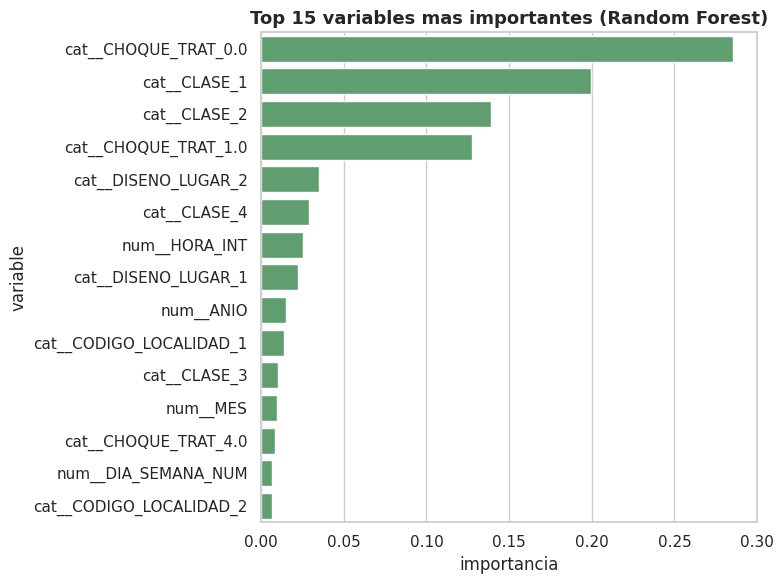

,variable,importancia
27,cat__CHOQUE_TRAT_0.0,0.285720
20,cat__CLASE_1,0.199285
21,cat__CLASE_2,0.138786
28,cat__CHOQUE_TRAT_1.0,0.127284
38,cat__DISENO_LUGAR_2,0.034816
23,cat__CLASE_4,0.028863
56,num__HORA_INT,0.025474
33,cat__DISENO_LUGAR_1,0.022572
58,num__ANIO,0.014837
0,cat__CODIGO_LOCALIDAD_1,0.013676


In [31]:
# Se usa el pipeline de Random Forest para la importancia de variables: es un modelo de arboles
# con 'feature_importances_' nativo (a diferencia de HistGradientBoosting, que no expone este atributo
# directamente); si Random Forest fue tambien el mejor modelo, esto coincide con 'mejor_pipeline'.
modelo_arboles = pipelines_finales['Random Forest']

feature_names = modelo_arboles.named_steps['prep'].get_feature_names_out()
importancias = modelo_arboles.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'variable': feature_names, 'importancia': importancias})
imp_df = imp_df.sort_values('importancia', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(data=imp_df, y='variable', x='importancia', ax=ax, color='#55A868')
ax.set_title('Top 15 variables mas importantes (Random Forest)')
plt.tight_layout()
plt.show()
imp_df

**Interpretación de la importancia de variables:**

Las variables relacionadas con el **tipo de choque** (`CHOQUE_TRAT`) y la **clase de siniestro** (`CLASE`) dominan claramente el ranking: `CHOQUE_TRAT = "No aplica"` (28,6%, es decir, siniestros que no son choques: atropellos, volcamientos, caídas de ocupante, etc.), `CLASE = Choque` (19,9%), `CLASE = Atropello` (13,9%) y `CHOQUE_TRAT = "Con vehículo"` (12,7%) suman más del **75% de la importancia total**. Las variables de diseño del lugar, hora, localidad, año y mes aportan cada una menos del 4%.

Esto es consistente con la literatura de seguridad vial: **la naturaleza del siniestro (si involucra un actor vulnerable como peatón, o si es un choque simple entre vehículos) es mucho más determinante de si habrá víctimas que el dónde o el cuándo ocurre**. Un atropello o un siniestro que no es un choque convencional (volcamiento, caída de ocupante) tiene, por su propia naturaleza física, mayor probabilidad de producir heridos o muertos que un choque entre dos vehículos con daños materiales.

---
# 7. Integración y Conclusiones

## 7.1 Conexión entre la tarea descriptiva y la predictiva

Una pregunta natural que conecta ambas tareas es: **¿el riesgo de que un siniestro tenga víctimas (medido por el modelo predictivo) varía según el perfil/cluster al que pertenece el siniestro?** Si la respuesta es sí, los clusters no solo agrupan siniestros por contexto físico/temporal, sino que también son un proxy útil de riesgo, reforzando su valor para priorizar intervenciones.

In [32]:
# Probabilidad predicha (mejor modelo) para TODOS los registros, cruzada con el cluster
proba_todos = mejor_pipeline.predict_proba(X)[:, 1]
df['PROB_CON_VICTIMAS'] = proba_todos

integracion = df.groupby('CLUSTER').agg(
    n_siniestros=('CODIGO_ACCIDENTE','count'),
    pct_real_con_victimas=('SINIESTRO_CON_VICTIMAS','mean'),
    prob_promedio_predicha=('PROB_CON_VICTIMAS','mean'),
).round(3)
integracion

,n_siniestros,pct_real_con_victimas,prob_promedio_predicha
CLUSTER,,,
0,42439,0.345,0.346
1,52663,0.337,0.338
2,48945,0.357,0.358
3,52105,0.352,0.351


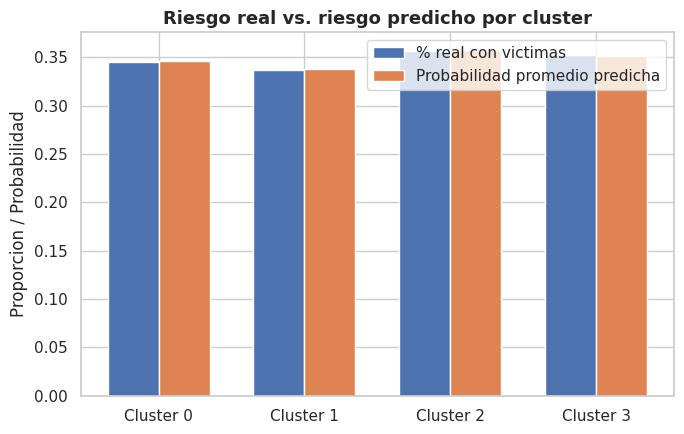

In [33]:
fig, ax = plt.subplots(figsize=(7,4.5))
x = np.arange(len(integracion))
width = 0.35
ax.bar(x - width/2, integracion['pct_real_con_victimas'], width, label='% real con victimas', color='#4C72B0')
ax.bar(x + width/2, integracion['prob_promedio_predicha'], width, label='Probabilidad promedio predicha', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {i}' for i in integracion.index])
ax.set_ylabel('Proporcion / Probabilidad')
ax.set_title('Riesgo real vs. riesgo predicho por cluster')
ax.legend()
plt.tight_layout()
plt.show()

**Hallazgo de integración:** el modelo predictivo asigna a cada cluster una probabilidad promedio de víctimas **prácticamente idéntica a la tasa real observada en ese cluster** (por ejemplo, Cluster 2: 35,7% real vs. 35,8% predicho; Cluster 1: 33,7% real vs. 33,8% predicho), y ambos coinciden en señalar al **Cluster 2 (100% fin de semana)** como el segmento de mayor riesgo relativo, y al **Cluster 1 (calles locales entre semana)** como el de menor riesgo relativo. Esto confirma dos cosas a la vez:

1. El modelo de clasificación es **internamente consistente** con la estructura no supervisada de los datos: aunque el clustering nunca usó la variable de gravedad para agruparse, el riesgo promedio predicho por el modelo reproduce casi exactamente el riesgo real dentro de cada segmento — el modelo no está "sorprendido" por ningún cluster en particular.
2. Sin embargo, la **magnitud** de la diferencia de riesgo entre clusters es modesta (33,7% a 35,7%, un rango de solo 2 puntos porcentuales), mientras que el modelo predictivo, al usar además `CLASE` y `CHOQUE_TRAT` como predictores (sección 6.3), sí logra una discriminación bastante mayor (AUC ≈ 0.80) a nivel de siniestro individual. Esto indica que **el contexto físico/temporal (dónde y cuándo) por sí solo no es suficiente para diferenciar el riesgo de víctimas** — el factor que realmente lo explica es la naturaleza del siniestro (choque vs. atropello vs. volcamiento, etc.), que es una variable *ortogonal* al segmento geográfico/temporal. Este es precisamente el tipo de hallazgo que conecta ambas tareas: el clustering aporta el eje *dónde/cuándo actuar*, y el modelo predictivo aporta el eje *qué tipo de siniestro prevenir*, y son complementarios porque miden cosas distintas.

## 7.2 Conclusiones y recomendaciones de negocio

1. **La naturaleza del siniestro —no el lugar ni el momento— es el factor más determinante de si habrá víctimas.** Las variables `CLASE` (tipo de siniestro) y `CHOQUE_TRAT` (subtipo de choque) concentran más del 75% de la importancia del mejor modelo (sección 6.3): los atropellos y los siniestros que no son choques simples (volcamientos, caídas de ocupante) son sistemáticamente más graves que un choque vehicular. Se recomienda a la SDM reforzar la protección de peatones y actores vulnerables (semaforización peatonal, reductores de velocidad, cruces seguros) de forma **transversal a toda la ciudad**, no solo en zonas específicas.

2. **El fin de semana es la ventana temporal de mayor riesgo relativo, aunque el efecto es moderado.** El Cluster 2 (100% fin de semana) presenta la mayor tasa real y predicha de siniestros con víctimas (35,7%/35,8%), casi 2 puntos porcentuales por encima del cluster de menor riesgo (calles locales entre semana, 33,7%). Se recomienda reforzar controles de velocidad y alcoholemia en las noches de viernes/sábado/domingo, como medida complementaria (no sustituta) a la recomendación anterior.

3. **El tipo de vía diferencia con claridad los perfiles de siniestralidad por contexto** (avenidas en la mañana entre semana vs. calles locales en la tarde vs. carreras en el norte vs. carreras de fin de semana). La estrategia de intervención de infraestructura debería diferenciarse por tipo de vía y franja horaria, en vez de aplicarse de forma homogénea a toda la ciudad.

4. **El poder predictivo del modelo (AUC ≈ 0,80-0,81) es bueno pero no perfecto**, lo cual es esperable: el dataset de `SINIESTROS` solo contiene variables de contexto (dónde, cuándo, qué tipo), sin variables de comportamiento (velocidad, alcoholemia, uso de casco/cinturón) que en la literatura de seguridad vial suelen explicar aún mejor la gravedad de un siniestro. Se recomienda a la SDM enriquecer el IPAT con estas variables (posiblemente cruzando con las hojas `ACTOR_VIAL` y `VEHICULOS` del mismo dataset, no usadas en este proyecto por alcance) para mejorar la capacidad predictiva de futuros modelos.

5. **La combinación de clustering + clasificación es más informativa que cualquiera de las dos técnicas por separado**: el clustering identifica *dónde/cuándo* concentrar recursos operativos (patrullaje, controles), mientras que el modelo de clasificación identifica *qué tipo de siniestro* priorizar en las campañas de prevención — juntos permiten a la SDM diseñar intervenciones focalizadas y basadas en evidencia, en vez de una estrategia única para toda la ciudad.

---
# 8. Comunicación y Documentación — Resumen Ejecutivo

*(Redactado para una audiencia no técnica: dirección de la Secretaría Distrital de Movilidad)*

**¿Qué se hizo?** Se analizaron **196.152 siniestros viales** ocurridos en Bogotá entre 2015 y 2020 (hoja `SINIESTROS` del dataset oficial de la SDM), combinando dos técnicas de analítica de datos: (1) una técnica de **segmentación** que agrupó los siniestros en **4 perfiles** según su contexto (zona, tipo de vía, día de la semana, franja horaria), y (2) una técnica de **predicción** que estima, a partir de esas mismas circunstancias más el tipo de siniestro, qué tan probable es que un siniestro tenga heridos o muertos (**34,8%** de los siniestros del histórico) y no solo daños materiales.

**¿Qué se encontró?**
- El **tipo de siniestro** (choque, atropello, volcamiento, etc.) es, por lejos, el factor más asociado a que existan víctimas: concentra más del 75% de la capacidad explicativa del modelo. Los atropellos y siniestros que no son choques simples son sistemáticamente más graves.
- Los siniestros de **fin de semana** forman un segmento propio y son el de mayor riesgo relativo (35,7% con víctimas frente a un mínimo de 33,7% en el segmento de menor riesgo), aunque la diferencia por contexto geográfico/temporal es más moderada que la diferencia por tipo de siniestro.
- El **tipo de vía** (avenida, carrera, calle) organiza de forma natural los patrones de siniestralidad por zona y horario, lo cual permite diferenciar estrategias de intervención según el tipo de infraestructura.
- El modelo predictivo (comparando 3 algoritmos distintos: Regresión Logística, Random Forest y HistGradientBoosting, este último el de mejor desempeño) alcanza una capacidad de discriminación de **~81% (AUC-ROC = 0,809)**, un desempeño bueno para un modelo construido únicamente con variables de contexto (sin datos de velocidad, alcoholemia o uso de elementos de protección).

**¿Qué se recomienda?**
1. Reforzar la protección de peatones y actores vulnerables (semaforización peatonal, reductores de velocidad) de forma transversal a toda la ciudad, ya que es el factor de mayor impacto sobre la gravedad.
2. Reforzar controles de velocidad y alcoholemia en horario nocturno de fin de semana, como medida complementaria.
3. Diferenciar la estrategia de intervención vial según el tipo de vía y franja horaria (avenidas en hora pico de la mañana vs. malla vial local vs. carreras).
4. Enriquecer los formularios de reporte de siniestros (IPAT) con variables de comportamiento (velocidad, alcoholemia, uso de elementos de protección) para mejorar la precisión de futuros modelos predictivos.

---
### Trazabilidad de entregables
- **Notebook:** este archivo, ejecutado de principio a fin sobre la hoja `SINIESTROS`.
- **Dataset:** `siniestros_viales_consolidados_bogota_dc.xlsx`, hoja `SINIESTROS` (Datos Abiertos Bogotá, Secretaría Distrital de Movilidad).
- **Informe/Presentación para audiencia no técnica:** el resumen ejecutivo de esta sección puede convertirse directamente en un informe corto o una presentación de máximo 10 diapositivas, siguiendo la misma estructura de hallazgos y recomendaciones.